# **online food analysis Project**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/ONINE_FOOD_DELIVERY_ANALYSIS.csv')

In [ ]:
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,NaN,NaN,Mumbai,NaN,RES295,Restaurant_500,Arabian,6/10/2024,...,132.0,Card,Delivered,NaN,DP835,2.0,4.0,Weekday,True,0.17
99996,ORD099997,CUST6158,NaN,Male,Mumbai,East,RES157,Restaurant_458,Arabian,4/22/2024,...,1078.0,NaN,Delivered,NaN,DP476,4.0,3.5,Weekday,False,-0.15
99997,ORD099998,CUST2155,NaN,NaN,Delhi,East,RES287,Restaurant_273,NaN,2/23/2024,...,NaN,COD,Cancelled,NaN,DP577,2.0,4.0,Weekday,True,0.47
99998,ORD099999,CUST3015,NaN,Female,Delhi,North,RES491,Restaurant_241,NaN,12/10/2024,...,NaN,NaN,Delivered,NaN,DP896,NaN,4.3,Weekday,NaN,0.44


In [ ]:
df.shape
df.columns
df.info()
df.isnull().sum()/len(df)*100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   object 
 4   City                 83274 non-null   object 
 5   Area                 83315 non-null   object 
 6   Restaurant_ID        100000 non-null  object 
 7   Restaurant_Name      100000 non-null  object 
 8   Cuisine_Type         83115 non-null   object 
 9   Order_Date           98986 non-null   object 
 10  Order_Time           98002 non-null   object 
 11  Delivery_Time_Min    66641 non-null   float64
 12  Distance_km          66530 non-null   float64
 13  Order_Value          66673 non-null   float64
 14  Discount_Applied     83285 non-null   float64
 15  Final_Amount      

,0
Order_ID,0.000
Customer_ID,0.000
Customer_Age,50.093
Customer_Gender,24.856
City,16.726
Area,16.685
Restaurant_ID,0.000
Restaurant_Name,0.000
Cuisine_Type,16.885
Order_Date,1.014


#converting order_date column to datatime

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Order_Time'] = pd.to_datetime(df['Order_Time'], errors='coerce').dt.time


# identifying the outliers for numeric columns

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
print("Numeric Columns:\n", numeric_cols)

Numeric Columns:
 Index(['Customer_Age', 'Delivery_Time_Min', 'Distance_km', 'Order_Value',
       'Discount_Applied', 'Final_Amount', 'Delivery_Rating',
       'Restaurant_Rating', 'Profit_Margin'],
      dtype='object')


In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) |
                    (data[column] > upper_bound)]

    return lower_bound, upper_bound, outliers.shape[0]

for col in numeric_cols:
    lb, ub, count = detect_outliers_iqr(df, col)
    print(f"{col} → Outliers: {count}")

Customer_Age → Outliers: 0
Delivery_Time_Min → Outliers: 0
Distance_km → Outliers: 0
Order_Value → Outliers: 0
Discount_Applied → Outliers: 16600
Final_Amount → Outliers: 0
Delivery_Rating → Outliers: 0
Restaurant_Rating → Outliers: 0
Profit_Margin → Outliers: 0


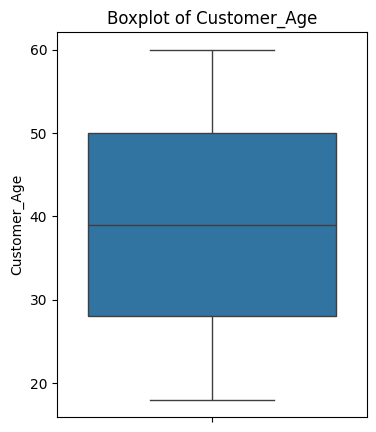

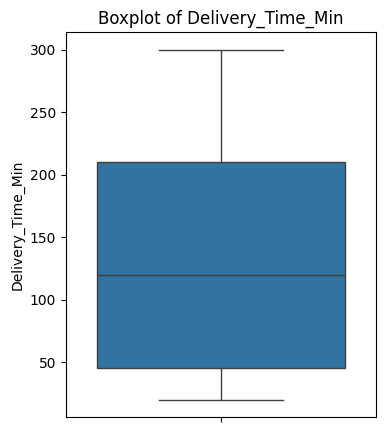

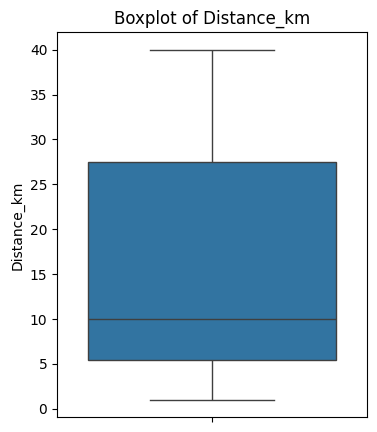

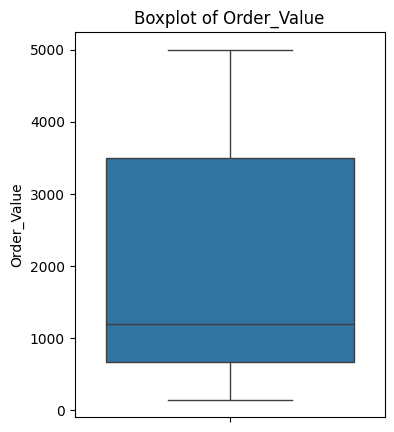

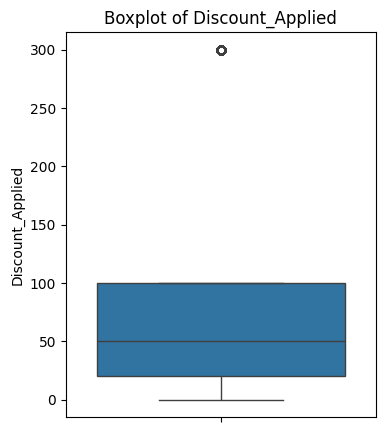

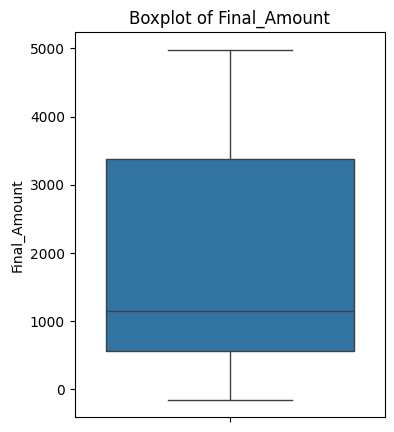

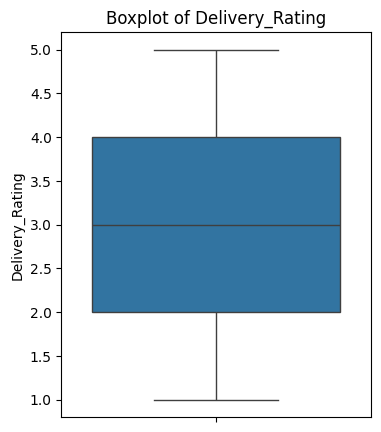

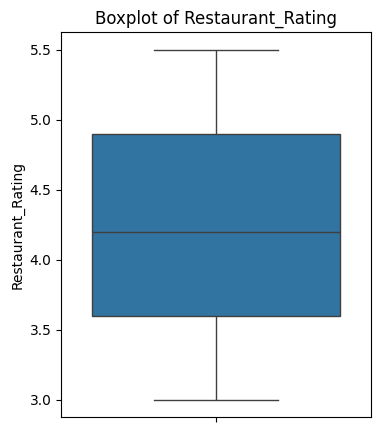

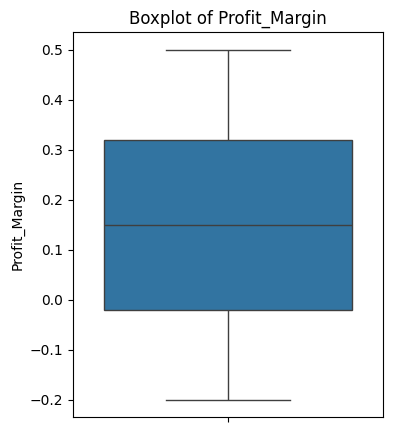

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(4,5))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Handling Missing Values

In [ ]:
#using ffill and bfill to fill the NaT rows
df['Order_Date']=df['Order_Date'].ffill().bfill()

In [ ]:
#filling Nan rows to 0 because 0 means no discount so this makes sense
df['Discount_Applied'].fillna(0, inplace=True)

/tmp/ipykernel_1697/1157214198.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Discount_Applied'].fillna(0, inplace=True)


In [ ]:
#filling order_value column
df['Order_Value'] = df['Order_Value'].fillna(
    df.groupby('Restaurant_ID')['Order_Value'].transform('median')
)

In [ ]:
#filling final_amount
df['Final_Amount']= df['Order_Value'] - df['Discount_Applied']

In [ ]:
df.groupby('Order_Status')['Delivery_Time_Min'].count()

,Delivery_Time_Min
Order_Status,
Cancelled,10006
Delivered,56635


In [ ]:
df.groupby('Order_Status')['Delivery_Time_Min'].apply(lambda x: x.isnull().sum())

,Delivery_Time_Min
Order_Status,
Cancelled,5030
Delivered,28329


In [ ]:
#filling missing values in city by using mode function from Restaurant_ID
df['City'] = df.groupby('Restaurant_ID')['City'] \
.transform(
 (lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)))

In [ ]:
#filling missing values in Area by using mode function from Restaurant_ID and City
df['Area']=df.groupby(['City','Restaurant_ID'])['Area'] \
.transform((lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)))

In [ ]:
#filling NaN rows of Customer_Gender as 'unknown'
df['Customer_Gender'] = df['Customer_Gender'].fillna('Unknown')

In [ ]:
#filling Customer_Age using median function from City
df['Customer_Age'] = df.groupby('City')['Customer_Age'] \
 .transform(lambda x: x.fillna(x.median()))

In [ ]:
#filling Cuisine_Type column by using mode function from Restaurant_ID
df['Cuisine_Type'] = df.groupby('Restaurant_ID')['Cuisine_Type'] \
.transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

In [ ]:
# Step 1: City + Area median
df['Distance_km'] = df.groupby(['City','Area'])['Distance_km'] \
                       .transform(lambda x: x.fillna(x.median()))

# Step 2: Restaurant-level median (sometimes useful)
df['Distance_km'] = df.groupby('Restaurant_ID')['Distance_km'] \
                       .transform(lambda x: x.fillna(x.median()))

# Step 3: City-level median
df['Distance_km'] = df.groupby('City')['Distance_km'] \
                       .transform(lambda x: x.fillna(x.median()))

# Step 4: Final global fallback
df['Distance_km'].fillna(df['Distance_km'].median(), inplace=True)

/tmp/ipykernel_1697/2867060384.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Distance_km'].fillna(df['Distance_km'].median(), inplace=True)


In [ ]:
#filling the Peak_Hour by using mode from the City and Order_Day columns
df['Peak_Hour'] = df.groupby(['City','Order_Day'])['Peak_Hour'] \
.transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

/tmp/ipykernel_1697/3618943184.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))


In [ ]:
#before filling Cancellation_Reason ,here i used to understand the ratio of filled Cancellation_Reason
df[df['Order_Status']=='Cancelled']['Cancellation_Reason'].value_counts(normalize=True)

,proportion
Cancellation_Reason,
Late Delivery,0.338722
Customer Cancelled,0.331414
Restaurant Issue,0.329864


In [ ]:
#for deliverd i filled NaN as Not_Cancelled
df.loc[df['Order_Status'] == 'Delivered', 'Cancellation_Reason'] = 'Not_Cancelled'

In [ ]:
# filled Cancellation_Reason by Using Stochastic (Probabilistic) Imputation,
cancel_mask = (
    (df['Order_Status']=='Cancelled') &
    (df['Cancellation_Reason'].isna())
)

known_reasons = df[
    (df['Order_Status']=='Cancelled') &
    (df['Cancellation_Reason'].notna())
]['Cancellation_Reason']

probs = known_reasons.value_counts(normalize=True)

df.loc[cancel_mask, 'Cancellation_Reason'] = np.random.choice(
    probs.index,
    size=cancel_mask.sum(),
    p=probs.values
)

In [ ]:
df.loc[df['Order_Status'] == 'Cancelled', 'Delivery_Time_Min'] = np.nan

In [ ]:
df.loc[df['Order_Status'] == 'Cancelled', 'Distance_km'] = np.nan

In [ ]:
df.loc[df['Order_Status'] == 'Cancelled', 'Delivery_Rating'] = np.nan

In [ ]:
#filling only Delivered rows of Delivery_Time_Min by using mean function
mask = (df['Order_Status'] == 'Delivered') & (df['Delivery_Time_Min'].isna())

df.loc[mask, 'Delivery_Time_Min'] = df.groupby('Distance_km')['Delivery_Time_Min'] \
                                      .transform('median')[mask]

In [ ]:
#filling only Delivered rows of Delivery_Time_Min by using mean function taking from 'city'
mask = (df['Order_Status'] == 'Delivered') & (df['Delivery_Time_Min'].isna())

df.loc[mask, 'Delivery_Time_Min'] = df.groupby('City')['Delivery_Time_Min'] \
                                      .transform('median')[mask]

In [ ]:
df[['City','Order_Status']]

,City,Order_Status
0,Hyderabad,Delivered
1,Chennai,Delivered
2,Delhi,Delivered
3,Mumbai,Cancelled
4,Chennai,Delivered
...,...,...
99995,Mumbai,Delivered
99996,Mumbai,Delivered
99997,Delhi,Cancelled
99998,Delhi,Delivered


In [ ]:
#filled Delivery_Rating rating using median from Order_Status which is = 'Delivered'
df.loc[df['Order_Status'] == 'Delivered', 'Delivery_Rating'] = \
df[df['Order_Status'] == 'Delivered']['Delivery_Rating'] \
.transform(lambda x: x.fillna(x.median()))

In [ ]:
#creating distance bin column for easy visualization
df['Distance_Bin'] = pd.cut(
    df['Distance_km'],
    bins=[0, 2, 5, 10, 20, 40],
    labels=['Far', 'Near', 'Medium', 'Very_Near', 'Very_Far']
)

In [ ]:
#converting cancelled order payment mode to 'Order Cancelled' this makes sense
df.loc[df['Order_Status'] == 'Cancelled', 'Payment_Mode'] = 'Order Cancelled'

In [ ]:
df.groupby('Order_Status')['Payment_Mode'].apply(lambda x: x.isna().sum())

,Payment_Mode
Order_Status,
Cancelled,0
Delivered,16886


In [ ]:

# Mask for delivered orders with missing payment mode
mask = (
    (df['Order_Status'] == 'Delivered') &
    (df['Payment_Mode'].isna())
)

# Get distribution from known delivered payment modes
known_payments = df[
    (df['Order_Status'] == 'Delivered') &
    (df['Payment_Mode'].notna())
]['Payment_Mode']

probs = known_payments.value_counts(normalize=True)

# Fill missing using probability distribution
df.loc[mask, 'Payment_Mode'] = np.random.choice(
    probs.index,
    size=mask.sum(),
    p=probs.values
)

<Figure size 640x480 with 0 Axes>

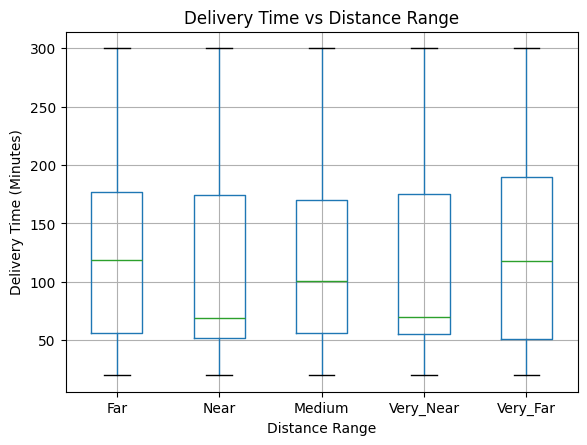

In [ ]:
# Only delivered orders
delivered_df = df[df['Order_Status'] == 'Delivered']

plt.figure()

delivered_df.boxplot(
    column='Delivery_Time_Min',
    by='Distance_Bin'
)

plt.suptitle("")  # removes automatic title
plt.title("Delivery Time vs Distance Range")
plt.xlabel("Distance Range")
plt.ylabel("Delivery Time (Minutes)")

plt.show()

In [ ]:
df.loc[df['Delivery_Time_Min'] < 0, 'Delivery_Time_Min'] = None
df.loc[df['Delivery_Time_Min'] > 300, 'Delivery_Time_Min'] = None


In [ ]:
mask = (df['Order_Status'] == 'Delivered') & (df['Delivery_Time_Min'].isna())

df.loc[mask, 'Delivery_Time_Min'] = df.groupby(
    ['City','Distance_Bin']
)['Delivery_Time_Min'].transform('median')[mask]

/tmp/ipykernel_1697/714449705.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.loc[mask, 'Delivery_Time_Min'] = df.groupby(


In [ ]:
df['Delivery_Time_Min'].describe()

,Delivery_Time_Min
count,84964.000000
mean,119.671273
std,79.620139
min,20.000000
25%,54.000000
50%,96.500000
75%,178.000000
max,300.000000
